In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids

## Load and Preprocess the Dataset

In [ ]:
# pip install "numpy<2"

In [ ]:
# Generate a synthetic dataset with 300 samples and 2 features
data = make_blobs(n_samples=300, centers=4, n_features=2, random_state=42)

# Standardize the dataset
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[0])

## K-Means Clustering

In [ ]:
def initialize_centroids(data, k):
    """Randomly initialize the centroids from the data points."""
    np.random.seed(42)
    random_indices = np.random.choice(data.shape[0], size=k, replace=False)
    centroids = data[random_indices]
    return centroids

def compute_distances(data, centroids):
    """Compute the distances between each data point and centroids."""
    distances = np.zeros((data.shape[0], centroids.shape[0]))
    for i, centroid in enumerate(centroids): distances[:, i] = np.linalg.norm(data - centroid, axis=1)
    return distances

def assign_clusters(distances):
    """Assign each data point to the closest centroid."""
    # np.argmin returns the index of the smallest value in each row
    return np.argmin(distances, axis=1)

def update_centroids(data, clusters, k):
    """Update the centroids by computing the mean of the points in each cluster."""
    new_centroids = np.zeros((k, data.shape[1]))
    for i in range(k):
        cluster_points = data[clusters == i]
        if len(cluster_points) > 0: new_centroids[i] = np.mean(cluster_points, axis=0)
    return new_centroids

def k_means(data, k, max_iterations=100):
    """Implement the K-means clustering algorithm."""
    centroids = initialize_centroids(data, k)

    for _ in range(max_iterations):
        distances = compute_distances(data, centroids)        # Step 1: Compute Distances from data points to centroids
        clusters = assign_clusters(distances)                 # Step 2: Assign Clusters
        new_centroids = update_centroids(data, clusters, k)   # Step 3: Update Centroids
        if np.allclose(centroids, new_centroids): break       # Step 4: Check Convergence

        centroids = new_centroids

    return centroids, clusters

### Run K-Means and Plot Results

K-Means (scratch) -> Total WCSS: 69.93


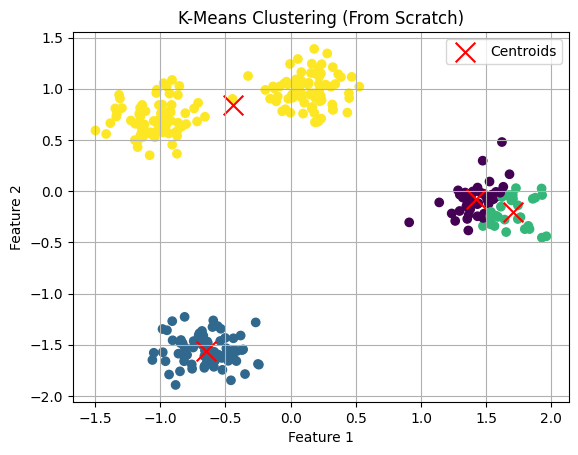

In [ ]:
k = 4 # Number of CLusters
centroids, clusters = k_means(data_scaled, k)
wcss = np.sum([np.sum(np.square(data_scaled[clusters == i] - centroids[i])) for i in range(k)])
print("K-Means (scratch) -> Total WCSS:", round(wcss, 2))

# Plot
plt.scatter(data_scaled[:, 0], data_scaled[:, 1], c=clusters, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, label='Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering (From Scratch)')
plt.grid(True)
plt.legend()
plt.show()

### Exercise 2: K-Medoids Clustering From Scratch

In [ ]:
def compute_total_cost(data, medoid_indices, labels):
    """Calculate total distance of all points to their assigned medoid."""
    total_cost = 0
    for i, point in enumerate(data):
        medoid = data[medoid_indices[labels[i]]]
        total_cost += np.linalg.norm(point - medoid)
    return total_cost

def k_medoids_scratch(data, k, max_iterations=100):
    np.random.seed(42)
    # Step 1: Initialize Medoids
    medoid_indices = np.random.choice(data.shape[0], size=k, replace=False)

    for _ in range(max_iterations):
        # Step 2: Assign clusters
        distances = np.array([[np.linalg.norm(p - data[m]) for m in medoid_indices] for p in data])
        labels = np.argmin(distances, axis=1)
        new_medoid_indices = np.zeros(k, dtype=int)

        # Step 3: Update Medoids
        for i in range(k):
            cluster_points_indices = np.where(labels == i)[0]
            if len(cluster_points_indices) > 0: # Find which point in the cluster is the best medoid
                costs = []
                for candidate_idx in cluster_points_indices:
                    total_dist = np.sum([np.linalg.norm(data[candidate_idx] - data[other_idx]) for other_idx in cluster_points_indices])
                    costs.append(total_dist)

                new_medoid_indices[i] = cluster_points_indices[np.argmin(costs)]

            else: new_medoid_indices[i] = medoid_indices[i]

        if np.array_equal(medoid_indices, new_medoid_indices): break # Check if stop Changing
        medoid_indices = new_medoid_indices

    medoids = data[medoid_indices]
    return medoids, labels, medoid_indices

#### Run K-Medoids and Plot Results


K-Medoids (scratch) - Total Cost: 21.0


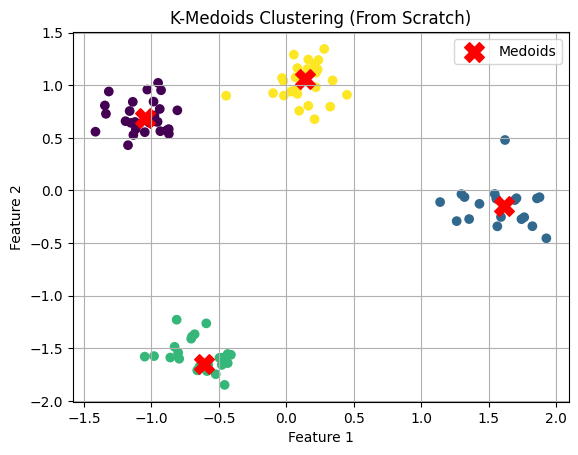

In [ ]:
data_small = data_scaled[:100]

medoids_scratch, medoid_labels, medoid_idx_list = k_medoids_scratch(data_small, k=4)
total_cost_scratch = compute_total_cost(data_small, medoid_idx_list, medoid_labels)
print("K-Medoids (scratch) - Total Cost:", round(total_cost_scratch, 2))

# Plot
plt.scatter(data_small[:, 0], data_small[:, 1], c=medoid_labels, cmap='viridis')
plt.scatter(medoids_scratch[:, 0], medoids_scratch[:, 1], c='red', marker='X', s=200, label='Medoids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Medoids Clustering (From Scratch)')
plt.grid(True)
plt.legend()
plt.show()

#### Comparison: K-Means vs K-Medoids

In [ ]:
print("K-Means WCSS (scratch)   :", round(wcss, 2))
print("K-Medoids Cost (scratch) :", round(total_cost_scratch, 2))

K-Means WCSS (scratch)   : 69.93
K-Medoids Cost (scratch) : 21.0


In [ ]:
print("K-Means   -> centroid = MEAN of cluster (not always a real point)")
print("K-Medoids -> medoid  = ACTUAL data point (always exists in data)")

K-Means   -> centroid = MEAN of cluster (not always a real point)
K-Medoids -> medoid  = ACTUAL data point (always exists in data)


In [ ]:
print("Which is better?")
print("On clean, blob-shaped data: both perform similarly.")
print("With outliers: K-Medoids is more robust because the medoid cannot be dragged far by an extreme value.")
print("Speed: K-Means is much faster (O(n x k)), K-Medoids is slow (O(n^2 x k)).")

Which is better?
On clean, blob-shaped data: both perform similarly.
With outliers: K-Medoids is more robust because the medoid cannot be dragged far by an extreme value.
Speed: K-Means is much faster (O(n x k)), K-Medoids is slow (O(n^2 x k)).


### Exercise 3: Clustering with Built-in Libraries

In [ ]:
df = pd.read_csv('Mall_Customers.csv')
df = df.dropna()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19.0,15.0,39
1,2,Male,21.0,15.0,81
2,3,Female,20.0,16.0,6
3,4,Female,23.0,16.0,77
4,5,Female,31.0,17.0,40


In [ ]:
# Use Annual Income and Spending Score as features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
scaler2 = StandardScaler()
X_scaled = scaler2.fit_transform(X)

#### Elbow Method -> K-Means

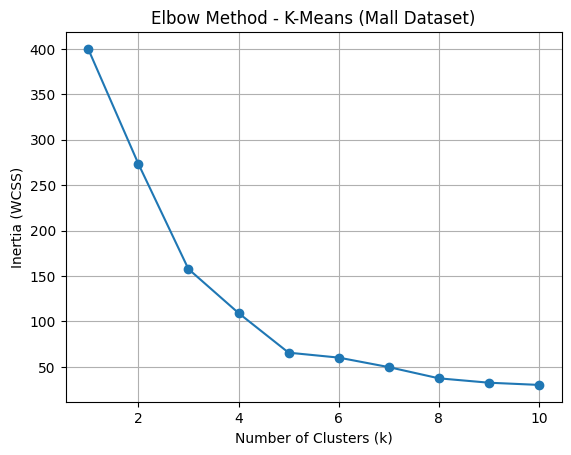

Look at the plot: the elbow (sharpest bend) gives the optimal k.
For this dataset the elbow is typically at k = 5.


In [ ]:
inertia_list = [] # Test k values from 1 to 10

for k_val in range(1, 11):
    km = KMeans(n_clusters=k_val, random_state=42)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)

# Plot
plt.plot(range(1, 11), inertia_list, marker='o')
plt.title('Elbow Method - K-Means (Mall Dataset)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True)
plt.show()

print("Look at the plot: the elbow (sharpest bend) gives the optimal k.")
print("For this dataset the elbow is typically at k = 5.")

#### Apply Built-in K-Means with Optimal k

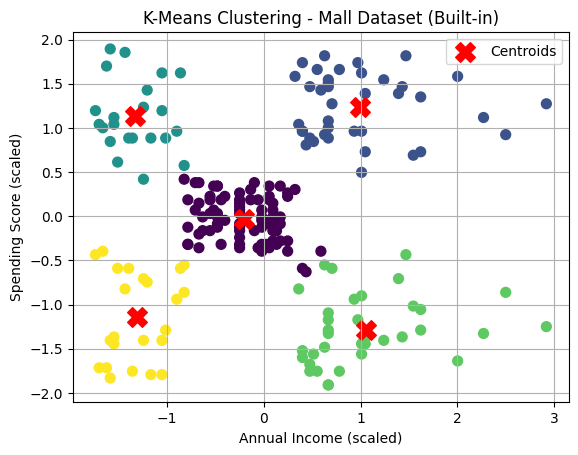

In [ ]:
best_k = 5  # chosen from the elbow method above

kmeans_builtin = KMeans(n_clusters=best_k, random_state=42)
kmeans_builtin.fit(X_scaled)

km_labels = kmeans_builtin.labels_
km_centers = kmeans_builtin.cluster_centers_

# Plot
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=km_labels, cmap='viridis', s=50)
plt.scatter(km_centers[:, 0], km_centers[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering - Mall Dataset (Built-in)')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.grid(True)
plt.legend()
plt.show()

#### Elbow Method -> K-Medoids (PAM)

/usr/local/lib/python3.12/dist-packages/sklearn_extra/cluster/_k_medoids.py:252: UserWarning: n_clusters should be larger than 2 if max_iter != 0 setting max_iter to 0.
  warnings.warn(


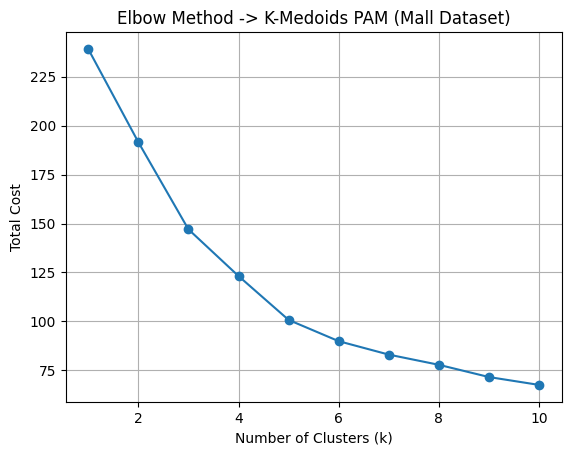

In [ ]:
# PAM uses total distance (not squared) as its cost
cost_list = []

for k_val in range(1, 11):
    kmed = KMedoids(n_clusters=k_val, method='pam', random_state=42)
    kmed.fit(X_scaled)
    cost_list.append(kmed.inertia_)

plt.plot(range(1, 11), cost_list, marker='o')
plt.title('Elbow Method -> K-Medoids PAM (Mall Dataset)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Total Cost')
plt.grid(True)
plt.show()

#### Apply Built-in K-Medoids with Optimal k

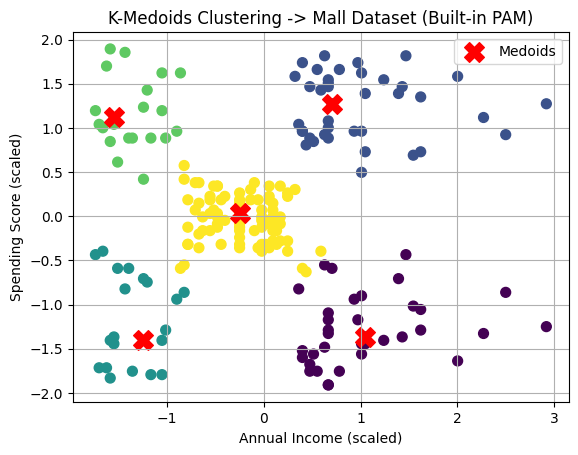

In [ ]:
kmedoids_builtin = KMedoids(n_clusters=best_k, method='pam', random_state=42)
kmedoids_builtin.fit(X_scaled)

kmed_labels = kmedoids_builtin.labels_
kmed_centers = kmedoids_builtin.cluster_centers_

# Plot
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmed_labels, cmap='viridis', s=50)
plt.scatter(kmed_centers[:, 0], kmed_centers[:, 1], c='red', marker='X', s=200, label='Medoids')
plt.title('K-Medoids Clustering -> Mall Dataset (Built-in PAM)')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.grid(True)
plt.legend()
plt.show()